This project implements a Real-Time Fake News Detection system using state-of-the-art Natural Language Processing (NLP) and ensemble Machine Learning (ML) methods. The system classifies news articles as fake or real and can analyze both historical and live news via NewsAPI. It was developed predominantly without the use of advanced AI assistants, emphasizing hands-on expertise in tackling misinformation.

In [88]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

WELFake is a curated dataset of 72,134 news articles (35,028 real / 37,106 fake) made by merging four popular sources, chosen for robust ML training and evaluation.

In [90]:
data = pd.read_csv("WELFake_Dataset.csv")
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [92]:
data.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [94]:
data.label.value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [96]:
df = data
df.shape

(72134, 4)

In [98]:
# Handle missing values without dropping rows
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

df['content'] = df['title'] + ' ' + df['text']

In [100]:
df.head()

,Unnamed: 0,title,text,label,content
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [102]:
df = df[['content', 'label']]

df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


# Exploratory Data Analysis

C:\Users\Soham Sarkar\AppData\Local\Temp\ipykernel_17052\3938166456.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=data, palette=['#55a868', '#c44e52'])
C:\Users\Soham Sarkar\AppData\Local\Temp\ipykernel_17052\3938166456.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Real News (0)', 'Fake News (1)'])


Class distribution plot saved as class_distribution.png


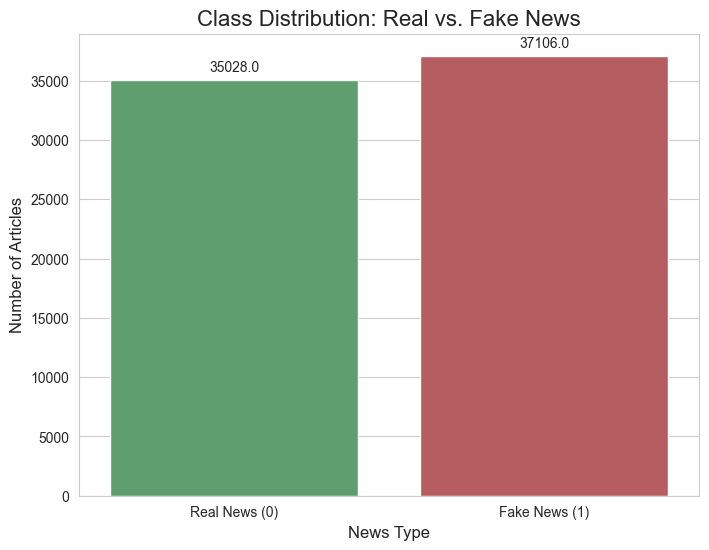

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='label', data=data, palette=['#55a868', '#c44e52'])

# Set plot title and labels
plt.title('Class Distribution: Real vs. Fake News', fontsize=16)
plt.xlabel('News Type', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

# Customize x-tick labels
ax.set_xticklabels(['Real News (0)', 'Fake News (1)'])

# Add annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Save the figure
plt.savefig('class_distribution.png')

print("Class distribution plot saved as class_distribution.png")

Title length distribution plot saved as title_length_distribution.png


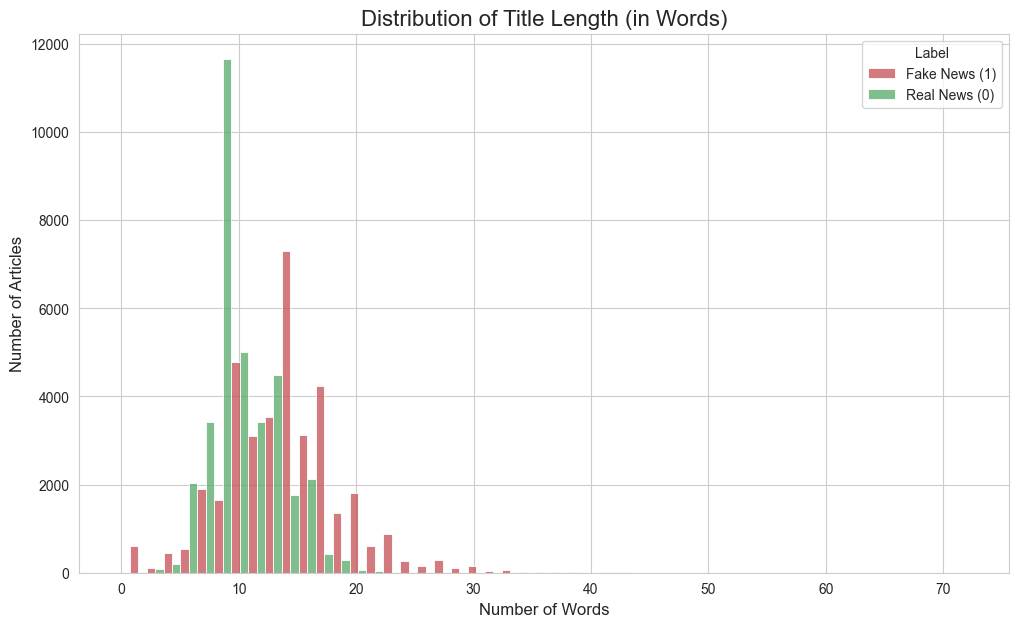

In [106]:
# Create a new column for the number of words in the title
data['title_word_count'] = data['title'].apply(lambda x: len(str(x).split()))

# Create the plot
plt.figure(figsize=(12, 7))
sns.histplot(data=data, x='title_word_count', hue='label', multiple='dodge', bins=50, palette=['#55a868', '#c44e52'])

# Set plot title and labels
plt.title('Distribution of Title Length (in Words)', fontsize=16)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.legend(title='Label', labels=['Fake News (1)', 'Real News (0)'])


# Save the figure
plt.savefig('title_length_distribution.png')

print("Title length distribution plot saved as title_length_distribution.png")

# Data Preprocessing

1.Cleans with regex: only a-zA-Z retained

2.Lowercases, lemmatizes (WordNet), removes stop-words using NLTK

In [108]:
stop_words = set(stopwords.words('english'))
lm = WordNetLemmatizer()

corpus = []

for text in df['content']:
    review = re.sub(r'[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()
    review = [lm.lemmatize(word) for word in review if word not in stop_words]
    review = " ".join(review)
    corpus.append(review)

In [38]:
len(corpus)

72134

In [40]:
df.content[0]

'LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:3

In [42]:
corpus[0]

'law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white people cop encouraged others radio show tuesday night turn tide kill white people cop send message killing black people america one f yoflag organizer called sunshine radio blog show hosted texas called sunshine f ing opinion radio show snapshot fyf lolatwhitefear twitter page p show urging supporter call fyf tonight continue dismantle illusion white snapshot twitter radio call invite fyf radio show aired p eastern standard time show caller clearly call lynching killing white people minute clip radio show heard provided breitbart texas someone would like referred hannibal already received death threat result interrupting fyf conference call unidentified black man said mother f kers start f ing like u bunch ni er takin one u roll said cause already roll gang anyway six seven black mother f c

# Vectorization (Convert Text data into the Vector)

In [45]:
tf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

X = tf.fit_transform(corpus)
y = df['label']

In [53]:
X.shape

(72134, 5000)

In [55]:
y.shape

(72134,)

# Data splitting into train and test

In [60]:
from sklearn.model_selection import train_test_split as ts

X_train, X_test, y_train, y_test = ts(X,y,test_size=0.3, random_state = 10, stratify = y)

#dataset is fairly balanced (about 51.4% fake news and 48.6% real news).
#Using stratify=y ensures that both your training and testing sets will also have this approximate 51/49 split

In [66]:
X_train.shape, y_train.shape

((50493, 5000), (50493,))

In [68]:
X_test.shape, y_test.shape

((21641, 5000), (21641,))

# Model Building

#### Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#### Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    random_state=10,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=30, n_estimators=300, n_jobs=-1,
                       random_state=10)

# Model Evaluation

In [80]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [82]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("=" * 60)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 60)

    print(f"\nTraining Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_test_pred))

In [84]:
evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: LogisticRegression

Training Accuracy : 0.9579
Testing Accuracy  : 0.9468

Confusion Matrix
[[ 9849   660]
 [  492 10640]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     10509
           1       0.94      0.96      0.95     11132

    accuracy                           0.95     21641
   macro avg       0.95      0.95      0.95     21641
weighted avg       0.95      0.95      0.95     21641



In [86]:
evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Model: RandomForestClassifier

Training Accuracy : 0.9933
Testing Accuracy  : 0.9542

Confusion Matrix
[[ 9796   713]
 [  278 10854]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     10509
           1       0.94      0.98      0.96     11132

    accuracy                           0.95     21641
   macro avg       0.96      0.95      0.95     21641
weighted avg       0.95      0.95      0.95     21641

